### Método de Tukey

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
def graficar_outliers(serie, fechas, outliers = None):
    ax = serie.plot(alpha = 0.7)

    serie.loc[fechas].plot(ax = ax, style = 'bo')

    if outliers is not None:
        outliers.plot(ax = ax, style = 'rx')
        plt.legend(['Serie de tiempo', 'Outliers conocidos', 'Outliers desconocidos'])
    else:
        plt.legend(['Serie de tiempo', 'Outliers conocidos'])
    
    plt.xlabel('Fecha')
    plt.ylabel('# pasajeros')

In [8]:
def outliers_Tukey(serie):
    q1, q3 = np.percentile(serie, [25, 75])

    IQR = q3 - q1

    lim_sup = q3 + 1.5*IQR
    lim_inf = q1 - 1.5*IQR

    outliers = serie[(serie.to_numpy() < lim_inf) | (serie.to_numpy() > lim_sup)]
    return outliers

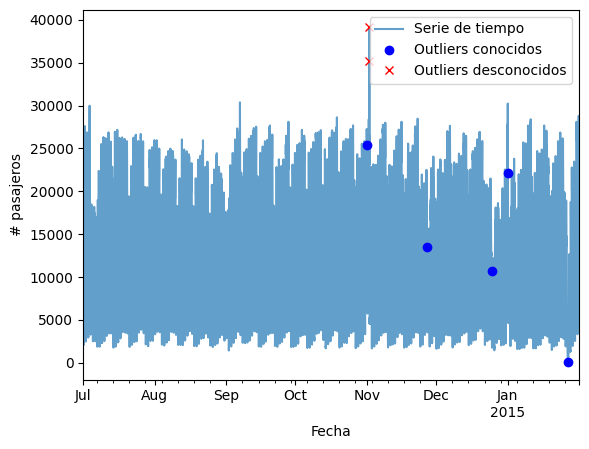

In [12]:
taxis = pd.read_csv('datos/taxis_ny.csv',
                    parse_dates=['tiempo'],
                    index_col='tiempo')
fechas = [
    '2014-11-01',
    '2014-11-27',
    '2014-12-25',
    '2015-01-01',
    '2015-01-27']

outliers = outliers_Tukey(taxis)

graficar_outliers(taxis, fechas, outliers)

Para el remuestreo diario

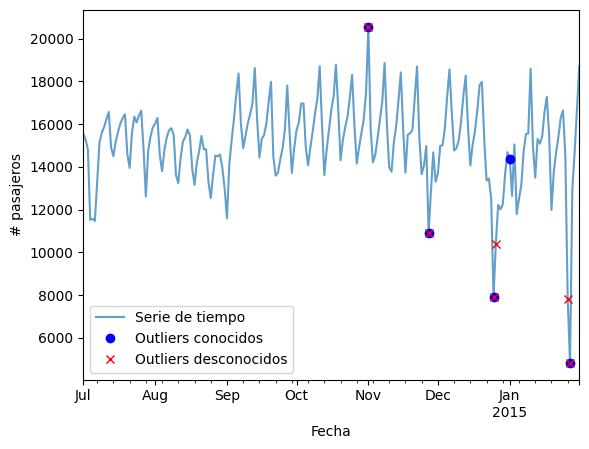

In [13]:
tx_diaria = taxis.resample('D').mean()
outliers_diario = outliers_Tukey(tx_diaria)

graficar_outliers(tx_diaria, fechas, outliers_diario)


<Axes: ylabel='Count'>

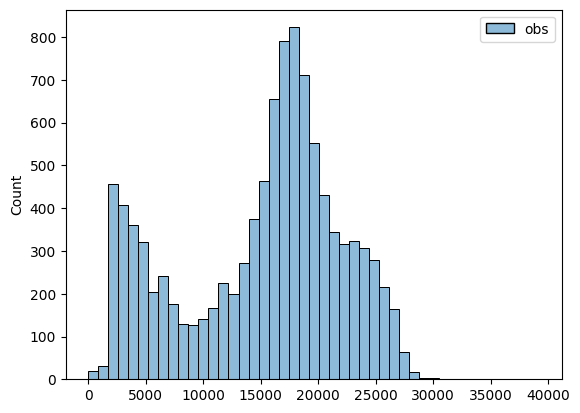

In [15]:
sns.histplot(taxis)

<Axes: ylabel='Count'>

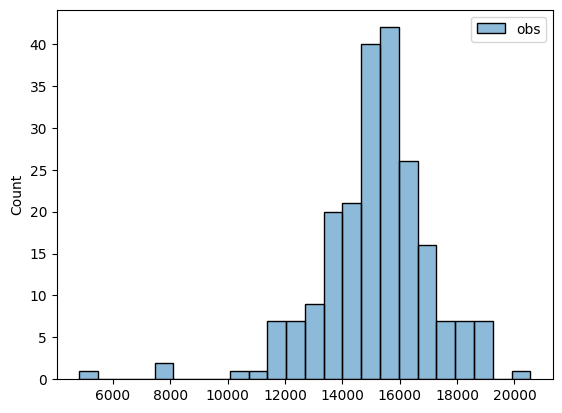

In [16]:
sns.histplot(tx_diaria)